# Heat Equation Interactive Demo

This notebook demonstrates explicit and Crank–Nicolson time integration using the `finite_differences` package.

- Use the code cells to modify `nx`, `ny`, `alpha`, `dt`, and `steps` and re-run.
- The grid is node-centered for Dirichlet boundary conditions (interior nodes at i*h, h = L/(n+1)).

In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
from finite_differences import Grid, Field
from finite_differences.bc import Dirichlet
from finite_differences.operators import laplacian, laplacian_5pt
from finite_differences.time_integrators import explicit_euler, crank_nicolson
from finite_differences.solvers import LinearSolver
from finite_differences.utils import quick_plot_2d

## Explicit solver (small interactive run)
The explicit cell-centered update uses ghost cells and the `laplacian` helper.

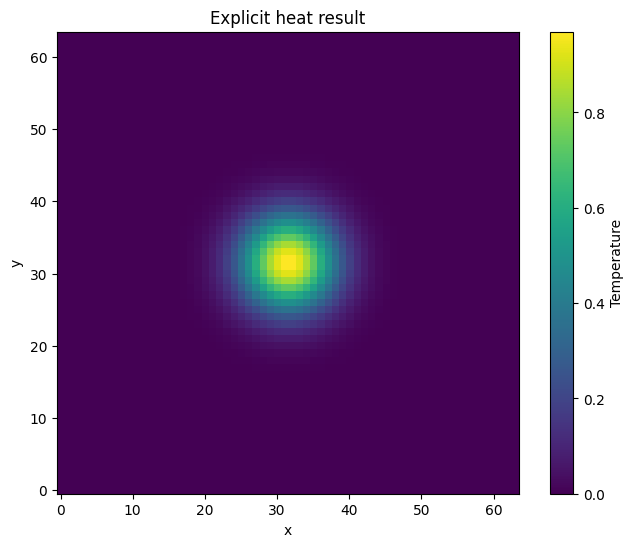

In [2]:
# Parameters (tweak and re-run)
nx = 64
ny = 64
alpha = 1e-3
dt = 5e-5
steps = 1000

# Setup grid and field
grid = Grid(nx, ny, lx=1.0, ly=1.0)
u = Field(grid, ng=1)
X, Y = grid.mesh()
u0 = np.exp(-((X - 0.5)**2 + (Y - 0.5)**2) / 0.01)
u.set_interior(u0)
bc = Dirichlet(0.0)

# Time stepping (explicit)
for n in range(steps):
    bc.apply(u)
    lap = laplacian(u)
    u.set_interior(u.interior + dt * alpha * lap)

# Plot result
fig, ax = quick_plot_2d(u.interior, title="Explicit heat result", xlabel='x', ylabel='y', cbarlabel='Temperature')
plt.show()

## Crank–Nicolson (implicit)
Use the sparse assembled Laplacian with the `LinearSolver` adapter.

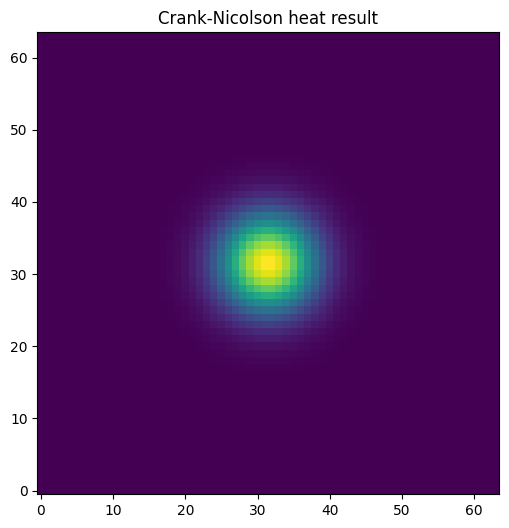

In [3]:
# Parameters (tweak and re-run)
nx = 64
ny = 64
alpha = 1e-3
dt = 1e-3
steps = 50

grid = Grid(nx, ny, lx=1.0, ly=1.0)
u = Field(grid, ng=1)
X, Y = grid.mesh()
u0 = np.exp(-((X - 0.5)**2 + (Y - 0.5)**2) / 0.01)
u.set_interior(u0)
bc = Dirichlet(0.0)
solver = LinearSolver()

for n in range(steps):
    bc.apply(u)
    u = crank_nicolson(u, laplacian_5pt, dt, alpha, solver)

bc.apply(u)
fig, ax = quick_plot_2d(u.interior, title="Crank-Nicolson heat result")
plt.show()

## Notes
- Adjust `dt` and `alpha` to explore stability and diffusion.
- For larger problems use the Crank–Nicolson cell which uses sparse solves.